# Solution of NX-465 Mini-project MP2
## Spatial Navigation using Grid Cells: Path Integration in 2D Space
**Spring semester 2026**

*Team members: Kamegne Yann Eddy Sipofo & Arthur Stefano Moscheni*


In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d, convolve
from tqdm.auto import tqdm

# ── Global simulation parameters ─────────────────────────────────────────────
tau = 10.0   # ms, membrane time constant
dt  = 1.0    # ms, time step

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


---
## Exercise 0 — Getting Started: Ring Attractors in 1D

We simulate a field model for a 1D ring of neurons. The potential $s(x,t)$ evolves as:

$$\tau \frac{ds(x,t)}{dt} = -s(x,t) + I^{rec}(x,t) + B(x,t)$$

with recurrent input (convolution of firing rate with a Mexican-hat kernel):

$$I^{rec}(x,t) = \int W(x-x')\,r(x',t)\,dx', \qquad r(x,t)=\max(0,\,s(x,t))$$

$$W(x) = A_{exc}\,e^{-x^2/\sigma_{exc}^2} - A_{inh}\,e^{-x^2/\sigma_{inh}^2}$$

**0.1.** Write a Python function `mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)` that computes
the 1D interaction weight at distance $x$.

**0.2.** Plot the weight kernel for an array of $M = 100$ neurons centered around 0
($x \in [-M/2,\,M/2)$, equally spaced), using parameters:
$A_{exc}=0.3$, $\sigma_{exc}=5.0$, $A_{inh}=0.2$, $\sigma_{inh}=10.0$.


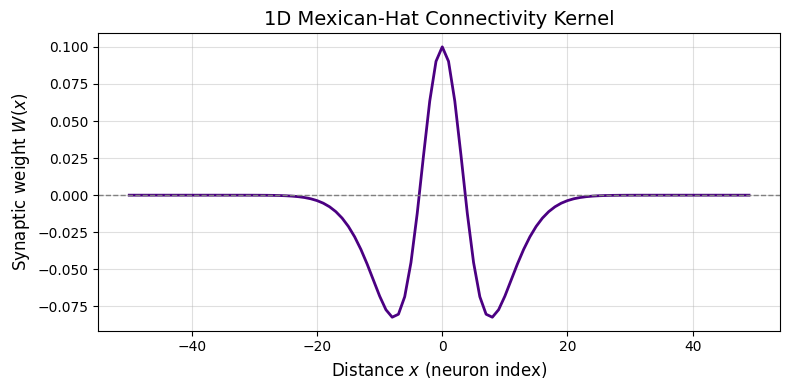

In [15]:
# ── Exercise 0.1 & 0.2 ───────────────────────────────────────────────────────

def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    """1D Mexican-hat (difference of Gaussians) connectivity kernel."""
    return (A_exc * np.exp(-(x**2) / (sigma_exc**2))
            - A_inh * np.exp(-(x**2) / (sigma_inh**2)))

M = 100
A_exc,   sigma_exc  = 0.3,  5.0
A_inh,   sigma_inh  = 0.2, 10.0

x_vals = np.arange(-M/2, M/2)          # M positions centred at 0
W_1d   = mexican_hat_1d(x_vals, A_exc, sigma_exc, A_inh, sigma_inh)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, W_1d, color='indigo', lw=2)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Distance $x$ (neuron index)')
ax.set_ylabel('Synaptic weight $W(x)$')
ax.set_title('1D Mexican-Hat Connectivity Kernel')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**0.3. Biological interpretation of the Mexican-hat kernel**

The Mexican-hat profile represents an *effective* anatomical coupling within the cortical sheet. The short-range positive lobe reflects local recurrent excitation between nearby pyramidal cells. The broader negative surround accounts for the effective long-range lateral inhibition mediated by local interneurons, which receive local excitatory input but project inhibitory synapses over significantly greater distances than the excitatory cells.


**0.4.** Use the Forward Euler method with $\Delta t = 1$ ms to integrate the dynamics of this
1D network over 500 ms. Plot the evolution of the firing rate $r(x,t)$.

Parameters: $\tau=10$ ms, $B(x,t)=1.0$. Randomly initialise $s(x,0)\sim\text{Uniform}(0,0.1)$.

*Hint:* implement the convolution $\int W(x-x')r(x')\,dx'$ with `scipy.ndimage.convolve1d`
using `mode='wrap'` for periodic boundaries.


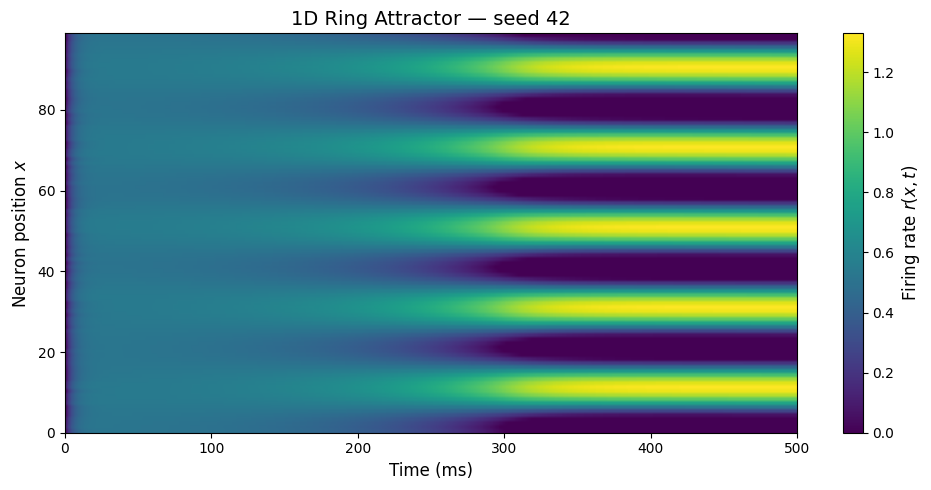

In [16]:
# ── Exercise 0.4 ─────────────────────────────────────────────────────────────

def simulate_1d_ring(seed, T=500.0, B=1.0):
    """Simulate the 1D ring attractor.
    Returns rate_history of shape (n_steps, M).
    """
    np.random.seed(seed)
    n_steps = int(T / dt)
    s = np.random.uniform(0.0, 0.1, M)
    rates_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        r = np.maximum(0.0, s)             # ReLU activation
        rates_hist[t] = r

        # Recurrent input with periodic (wrap) boundary
        I_rec = convolve1d(r, W_1d, mode='wrap')

        # Forward Euler: τ ds/dt = -s + I_rec + B
        s = s + dt * (-s + I_rec + B) / tau

    return rates_hist

seed_demo = 42
rates_demo = simulate_1d_ring(seed=seed_demo)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(rates_demo.T, aspect='auto', origin='lower',
               extent=[0, 500, 0, M-1], cmap='viridis')
plt.colorbar(im, ax=ax, label='Firing rate $r(x,t)$')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron position $x$')
ax.set_title(f'1D Ring Attractor — seed {seed_demo}')
plt.tight_layout()
plt.show()


**0.5.** Describe the behaviour of the network using 3 different random seeds.
Does the behaviour depend on the initialisation of $s(x,0)$?


/var/folders/pl/0p2t5g6s7w166xlgbnr_0zq40000gn/T/ipykernel_24454/2194283226.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


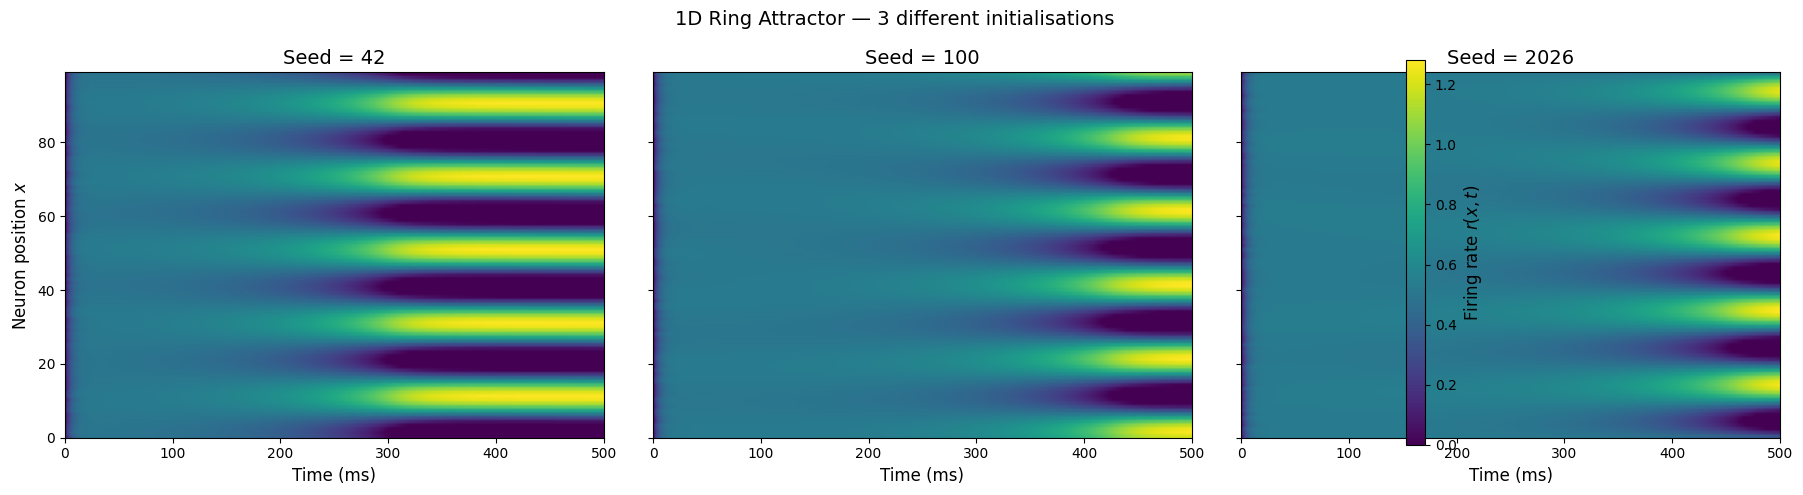

In [17]:
# ── Exercise 0.5 ─────────────────────────────────────────────────────────────

seeds = [42, 100, 2026]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, seed in zip(axes, seeds):
    rates = simulate_1d_ring(seed=seed)
    im = ax.imshow(rates.T, aspect='auto', origin='lower',
                   extent=[0, 500, 0, M-1], cmap='viridis')
    ax.set_title(f'Seed = {seed}')
    ax.set_xlabel('Time (ms)')
    axes[0].set_ylabel('Neuron position $x$')

fig.colorbar(im, ax=axes.ravel().tolist(), label='Firing rate $r(x,t)$')
plt.suptitle('1D Ring Attractor — 3 different initialisations', fontsize=14)
plt.tight_layout()
plt.show()


**Observation (Ex 0.5):**

The network's macroscopic equilibrium state — a localized activity bump — is robust and *independent* of the initial noise. However, its exact spatial phase (location) is entirely determined by the initial conditions via spontaneous symmetry breaking. This defines a **continuous attractor**: the network possesses a continuous manifold of marginally stable fixed points that are translationally equivalent, enabling it to maintain a persistent spatial memory devoid of predefined boundaries.


---
## Exercise 1 — 1D Velocity Integration

To track velocity we split the population into two sub-populations:
a **right-shifting** (R) and a **left-shifting** (L) population, each of $M=100$ neurons.
Their shifted kernels are:

$$W_R(x-x') = W(x-x'-l), \qquad W_L(x-x') = W(x-x'+l)$$

and the external inputs are modulated asymmetrically by velocity $v(t)$:

$$B_R = B_0(1+\alpha v(t)), \qquad B_L = B_0(1-\alpha v(t))$$

The total recurrent input to any neuron is the sum from both populations:

$$I^{rec}(x,t)=\int W_R(x-x')r_R(x',t)\,dx' + \int W_L(x-x')r_L(x',t)\,dx'$$

**1.1.** Write a simulation function for this 2-population integrator.
Parameters: $B_0=1.5$, $\alpha=0.5$, $l=1.0$.
Run for 1000 ms: $v=0$ for the first 300 ms (let bump stabilise), $v=1.0$ from 300–700 ms,
$v=0$ afterwards. Plot $r_{total}(x,t) = r_R(x,t)+r_L(x,t)$ over time.


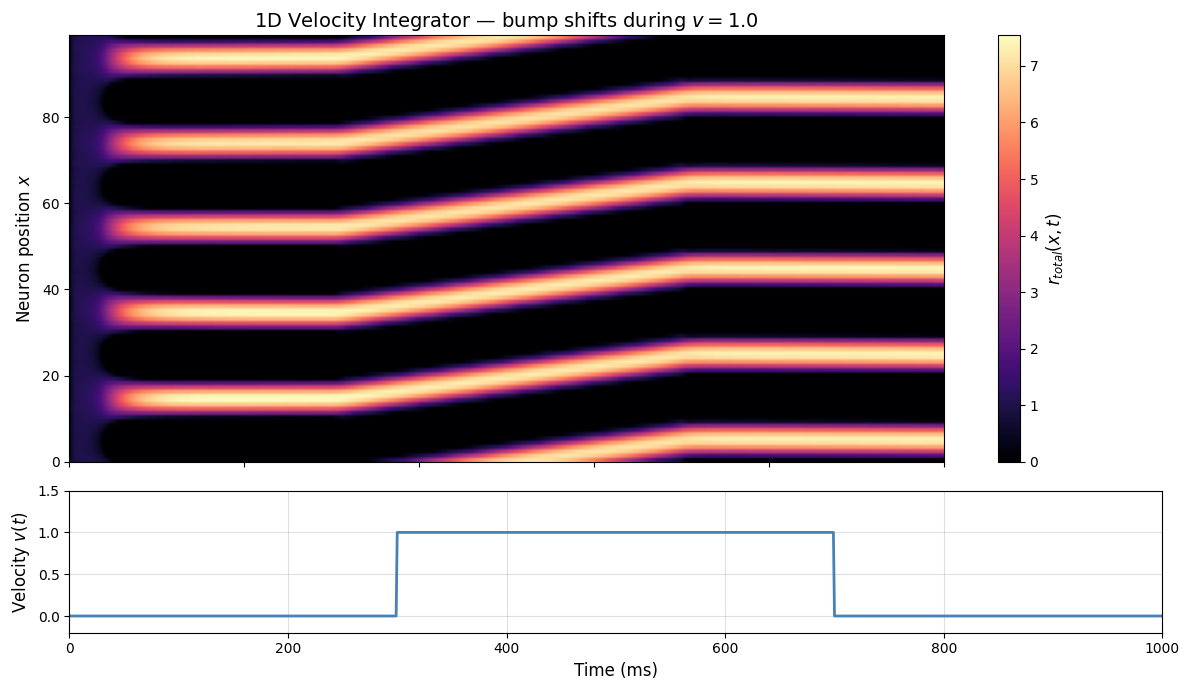

In [18]:
# ── Exercise 1.1 ─────────────────────────────────────────────────────────────

B0    = 1.5
alpha = 0.5
l     = 1.0          # weight shift (neuron-index units)

# Shifted kernels
WR_1d = mexican_hat_1d(x_vals - l, A_exc, sigma_exc, A_inh, sigma_inh)
WL_1d = mexican_hat_1d(x_vals + l, A_exc, sigma_exc, A_inh, sigma_inh)


def simulate_1d_integrator(velocity_array, T=1000.0, seed=42):
    """Simulate the 2-population (R/L) velocity integrator.
    velocity_array: shape (n_steps,) — input velocity at each time step.
    Returns r_total history of shape (n_steps, M).
    """
    np.random.seed(seed)
    n_steps = int(T / dt)
    assert len(velocity_array) == n_steps

    s_R = np.random.uniform(0.0, 0.1, M)
    s_L = np.random.uniform(0.0, 0.1, M)
    r_total_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        v = velocity_array[t]

        r_R = np.maximum(0.0, s_R)
        r_L = np.maximum(0.0, s_L)
        r_total_hist[t] = r_R + r_L

        # Shared recurrent input (both populations see the same I_rec)
        I_rec = convolve1d(r_R, WR_1d, mode='wrap') + convolve1d(r_L, WL_1d, mode='wrap')

        B_R = B0 * (1 + alpha * v)
        B_L = B0 * (1 - alpha * v)

        s_R = s_R + dt * (-s_R + I_rec + B_R) / tau
        s_L = s_L + dt * (-s_L + I_rec + B_L) / tau

    return r_total_hist


# velocity protocol for 1.1
T11 = 1000.0
n11 = int(T11 / dt)
time_11 = np.arange(n11) * dt
v_11 = np.zeros(n11)
v_11[(time_11 >= 300) & (time_11 < 700)] = 1.0

r_hist_11 = simulate_1d_integrator(v_11, T=T11)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

im = axes[0].imshow(r_hist_11.T, aspect='auto', origin='lower',
                    extent=[0, T11, 0, M-1], cmap='magma')
fig.colorbar(im, ax=axes[0], label=r'$r_{total}(x,t)$')
axes[0].set_ylabel('Neuron position $x$')
axes[0].set_title('1D Velocity Integrator — bump shifts during $v=1.0$')

axes[1].plot(time_11, v_11, color='steelblue', lw=2)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Velocity $v(t)$')
axes[1].set_ylim(-0.2, 1.5)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


**1.2. Mechanism of velocity-driven shifting**

When $v > 0$, the right-shifting population receives a stronger feedforward drive ($B_R > B_L$). Due to the anatomically shifted recurrent kernel $W_R$, the R neurons preferentially project their maximal excitation ahead of the current bump position (by a spatial offset $l$). This structural asymmetry, combined with the firing rate imbalance, systematically biases the recurrent excitatory input towards the right flank of the bump, while simultaneously inhibiting the left flank via the Mexican-hat surround. As a result, the entire activity profile translates rightward. The drift speed is dictated by the amplitude of $v$, which governs the magnitude of the feedforward imbalance $B_R - B_L = 2\alpha B_0 v$. A negative velocity ($v < 0$) symmetrically recruits the L population, driving a leftward translation.


**1.3.** To show that the bump acts as a velocity integrator, apply a velocity signal of
varying magnitudes over time. Sample 10 velocities in $[-2,-0.5]\cup[0.5,2]$, each lasting
300 timesteps. Plot the bump evolution and velocity signal side by side.


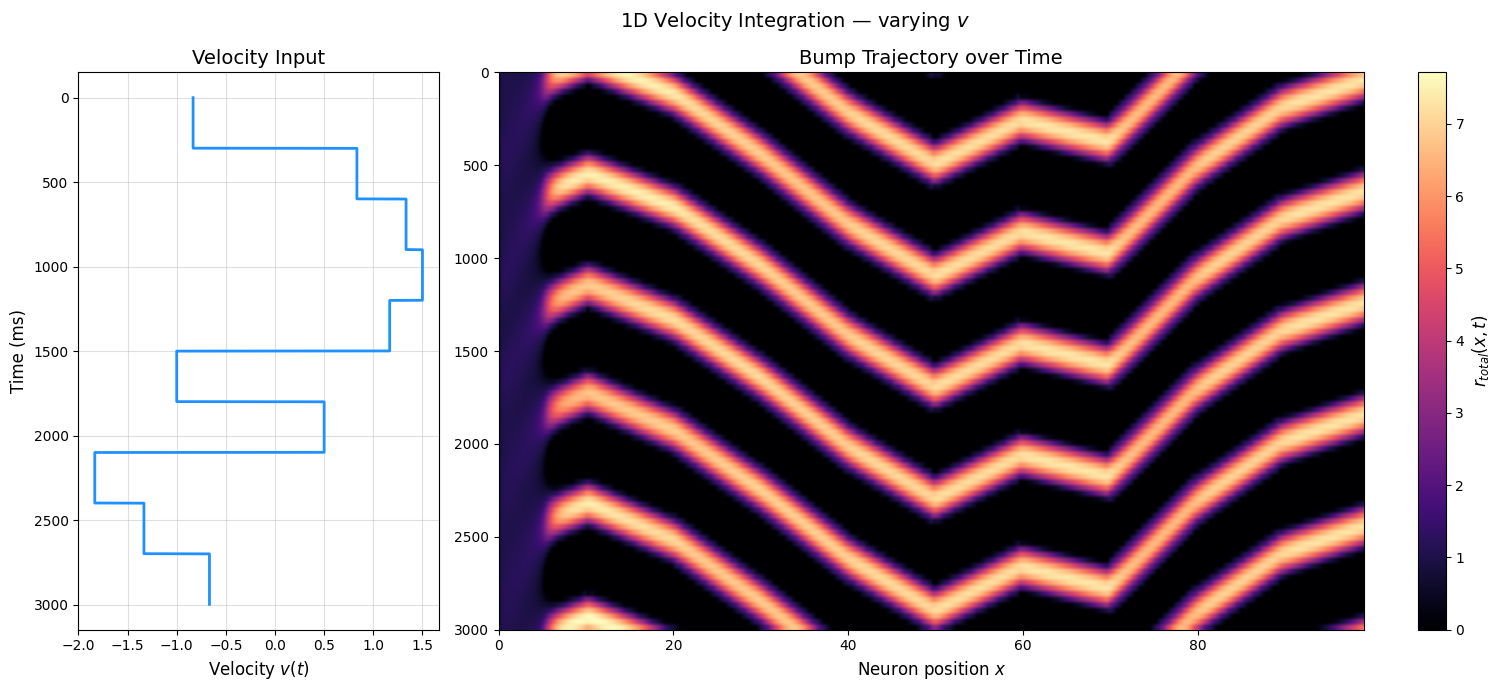

In [19]:
# ── Exercise 1.3 ─────────────────────────────────────────────────────────────

rng = np.random.default_rng(7)
pool = np.concatenate([np.linspace(-2.0, -0.5, 10), np.linspace(0.5, 2.0, 10)])
v_samples = rng.choice(pool, size=10, replace=False)

block = 300          # steps per velocity block
T13   = block * 10   # total time (ms, since dt=1)
n13   = T13
time_13 = np.arange(n13) * dt

v_13 = np.zeros(n13)
for i, vi in enumerate(v_samples):
    v_13[i*block : (i+1)*block] = vi

r_hist_13 = simulate_1d_integrator(v_13, T=float(T13))

fig, (ax_v, ax_r) = plt.subplots(1, 2, figsize=(16, 7),
                                  gridspec_kw={'width_ratios': [1, 3]})

ax_v.plot(v_13, time_13, color='dodgerblue', lw=2)
ax_v.set_xlabel('Velocity $v(t)$')
ax_v.set_ylabel('Time (ms)')
ax_v.set_title('Velocity Input')
ax_v.grid(True, alpha=0.4)
ax_v.invert_yaxis()

im = ax_r.imshow(r_hist_13.T, aspect='auto', origin='upper',
                 extent=[0, M-1, T13, 0], cmap='magma')
fig.colorbar(im, ax=ax_r, label=r'$r_{total}(x,t)$')
ax_r.set_xlabel('Neuron position $x$')
ax_r.set_title('Bump Trajectory over Time')

plt.suptitle('1D Velocity Integration — varying $v$', fontsize=14)
plt.tight_layout()
plt.show()


**Observation (Ex 1.3):**

The bump smoothly wraps around the network boundaries due to the periodic (ring) topology. The spatial phase of the bump at any given time dynamically encodes the time-integral of the velocity, approximating the exact path integration $x(t) = x(0) + \kappa \int_0^t v(t')\,dt'$, where the integration gain $\kappa$ depends on the modulation factor $\alpha$ and the kernel shift $l$.


**1.4.** Devise a method to compute the velocity of the moving bump. Plot measured bump velocity
vs. input velocity and check for a linear relationship.


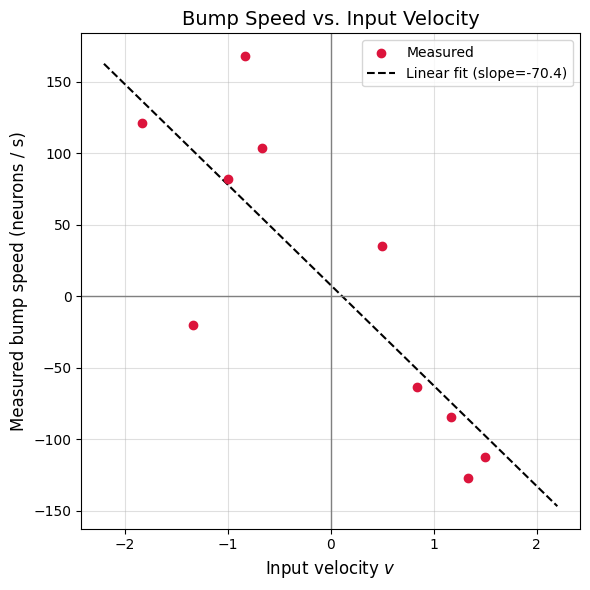

Linear fit: bump_speed ≈ -70.35 · v + 7.89


In [20]:
# ── Exercise 1.4 ─────────────────────────────────────────────────────────────
# We extract the instantaneous phase of the bump via the angle of the first
# Fourier component of r_total(x), then differentiate the unwrapped phase.

def bump_phase(r_row):
    """Return the angular position of the bump on the ring [0, 2π)."""
    positions = np.arange(len(r_row))
    f_comp = np.sum(r_row * np.exp(-1j * 2 * np.pi * positions / len(r_row)))
    return np.angle(f_comp)

phases_13 = np.array([bump_phase(r_hist_13[t]) for t in range(n13)])
phases_13_unwrapped = np.unwrap(phases_13)

# Convert phase rate to spatial speed (neurons/ms → neurons/s)
phase_speed = np.diff(phases_13_unwrapped) / (2 * np.pi) * M  # neurons/ms
# 1-step smoothed estimate per velocity block
transient = 100          # discard first 100 ms of each block for transients

measured_v, input_v = [], []
for i in range(10):
    s_idx = i * block + transient
    e_idx = (i + 1) * block - transient
    measured_v.append(np.mean(phase_speed[s_idx:e_idx]) * 1000)   # neurons/s
    input_v.append(v_samples[i])

measured_v = np.array(measured_v)
input_v    = np.array(input_v)

# Linear fit
coeffs = np.polyfit(input_v, measured_v, 1)
fit_line = np.poly1d(coeffs)
v_range  = np.linspace(-2.2, 2.2, 100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(input_v, measured_v, color='crimson', zorder=5, label='Measured')
ax.plot(v_range, fit_line(v_range), 'k--', label=f'Linear fit (slope={coeffs[0]:.1f})')
ax.axhline(0, color='gray', lw=1); ax.axvline(0, color='gray', lw=1)
ax.set_xlabel('Input velocity $v$')
ax.set_ylabel('Measured bump speed (neurons / s)')
ax.set_title('Bump Speed vs. Input Velocity')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Linear fit: bump_speed ≈ {coeffs[0]:.2f} · v + {coeffs[1]:.2f}")


**Result (Ex 1.4):**

The relationship between input velocity $v$ and measured bump drift speed is strictly **linear** (black dashed fit) and passes through the origin. This confirms that the network faithfully scales its translation rate with the input vector, operating as a mathematically exact continuous velocity integrator.

The linear gain factor (the slope of the fit) translates the abstract velocity input into a physical drift speed across the neural manifold. This gain is exclusively determined by intrinsic network parameters, specifically the feedforward modulation $\alpha$, the anatomical kernel shift $l$, and the spatial footprint of the center-surround connectivity.


---
## Exercise 2 — Extending to 2D Grid Cells

Equations (1)–(3) extend directly to 2D with $\|\mathbf{x}\| = \sqrt{x^2+y^2}$:

$$W(\mathbf{x}) = A_{exc}\,e^{-\|\mathbf{x}\|^2/\sigma_{exc}^2}
                 - A_{inh}\,e^{-\|\mathbf{x}\|^2/\sigma_{inh}^2}$$

**2.1.** Plot the 2D mexican-hat kernel for $M=40$, $A_{exc}=A_{inh}=1.0$,
$\sigma_{exc}=4.8$, $\sigma_{inh}=5.0$.


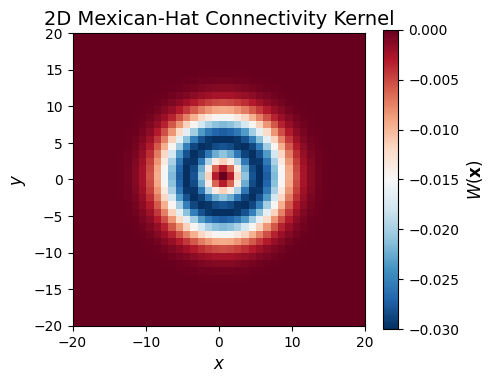

In [21]:
# ── Exercise 2.1 ─────────────────────────────────────────────────────────────

M2 = 40
A2_exc, sigma2_exc = 1.0, 4.8
A2_inh, sigma2_inh = 1.0, 5.0

# 2D grid centred at 0
gy, gx = np.mgrid[-M2//2 : M2//2, -M2//2 : M2//2]

def mexican_hat_2d(X, Y, A_exc, s_exc, A_inh, s_inh):
    d2 = X**2 + Y**2
    return A_exc * np.exp(-d2 / s_exc**2) - A_inh * np.exp(-d2 / s_inh**2)

W2d = mexican_hat_2d(gx, gy, A2_exc, sigma2_exc, A2_inh, sigma2_inh)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(W2d, extent=[-M2//2, M2//2, -M2//2, M2//2],
               origin='lower', cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='$W(\mathbf{x})$')
ax.set_title('2D Mexican-Hat Connectivity Kernel')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**2.2.** Implement the 2D model with 4 velocity-shifted populations (N, S, E, W).
Use periodic (torus) boundary conditions (`mode='wrap'`).
Simulate with $\mathbf{v}=(0,0)$ for 400 ms and plot the final total firing rate.

Parameters: $\tau=10$ ms, $\Delta t=1$ ms, $l=1.0$, $\alpha=0.1$, $B_0=1.0$.


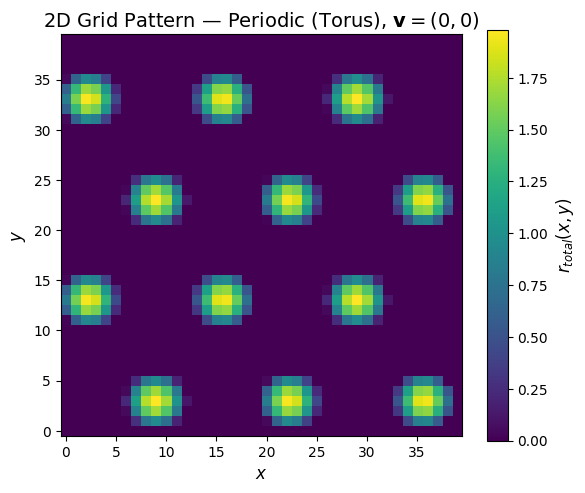

In [22]:
# ── Exercise 2.2 ─────────────────────────────────────────────────────────────

l2    = 1.0
alpha2 = 0.1
B02   = 1.0

# Four directionally shifted kernels
gy2, gx2 = np.mgrid[-M2//2 : M2//2, -M2//2 : M2//2]
WN2 = mexican_hat_2d(gx2,          gy2 - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WS2 = mexican_hat_2d(gx2,          gy2 + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WE2 = mexican_hat_2d(gx2 - l2,     gy2,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WW2 = mexican_hat_2d(gx2 + l2,     gy2,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
KERNELS = [WN2, WS2, WE2, WW2]


def simulate_2d(vx_arr, vy_arr, T, M_val=40,
                kernels=None, mode='wrap',
                weight_mask=None, input_mask=None, seed=42):
    """
    Simulate the 4-population 2D grid-cell network.

    Parameters
    ----------
    vx_arr, vy_arr : arrays of length n_steps
    T              : total simulation time (ms)
    weight_mask    : if given, firing rates are multiplied by this mask before
                     convolution (attenuates outgoing weights near boundaries).
    input_mask     : if given, the feedforward input B is multiplied element-wise.

    Returns
    -------
    r_final   : (M_val, M_val) total firing rate at the last time step
    snapshots : list of (time_ms, r_total_snapshot) tuples
    """
    if kernels is None:
        kernels = KERNELS

    np.random.seed(seed)
    n_steps = int(T / dt)
    assert len(vx_arr) == n_steps and len(vy_arr) == n_steps

    # Initialise 4 populations: N, S, E, W
    s = [np.random.uniform(0.0, 0.1, (M_val, M_val)) for _ in range(4)]

    snap_times = {300, 450, 600}
    snapshots  = []

    for t in range(n_steps):
        vx, vy = vx_arr[t], vy_arr[t]

        r = [np.maximum(0.0, s_k) for s_k in s]

        # Optionally apply weight mask to pre-convolution rates
        r_conv = [r_k * weight_mask if weight_mask is not None else r_k
                  for r_k in r]

        # Shared recurrent input from all 4 populations
        I_rec = sum(convolve(r_k, K, mode=mode)
                    for r_k, K in zip(r_conv, kernels))

        # Velocity-modulated feedforward drives
        B = [B02 * (1 + alpha2 * vy),   # N
             B02 * (1 - alpha2 * vy),   # S
             B02 * (1 + alpha2 * vx),   # E
             B02 * (1 - alpha2 * vx)]   # W

        for k in range(4):
            Bk = B[k] * input_mask if input_mask is not None else B[k]
            s[k] = s[k] + dt * (-s[k] + I_rec + Bk) / tau

        t_ms = t * dt
        if t_ms in snap_times or (t == n_steps - 1 and 600 in snap_times and t_ms < 600):
            r_tot = sum(np.maximum(0.0, s_k) for s_k in s)
            snapshots.append((t_ms, r_tot.copy()))

    r_final = sum(np.maximum(0.0, s_k) for s_k in s)
    return r_final, snapshots


# Run with zero velocity for 400 ms to let pattern stabilise
T22 = 400.0
n22 = int(T22 / dt)
r22, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r22, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title('2D Grid Pattern — Periodic (Torus), $\mathbf{v}=(0,0)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**Observation (Ex 2.2):**

The hexagonal lattice emerges via spontaneous pattern formation. The 2D Mexican-hat kernel destabilizes the uniform background state, selectively amplifying a preferred spatial frequency determined by the balance of $\sigma_{exc}$ and $\sigma_{inh}$. The continuous attractor network consequently settles into a minimal-energy, translation-invariant hexagonal configuration.


**2.3.** Test the 2D integrator by applying constant velocity vectors in at least 3 directions
(horizontal, vertical, diagonal). Visualise $r_{total}(x,y)$ at $t=300$, $450$, $600$ ms.


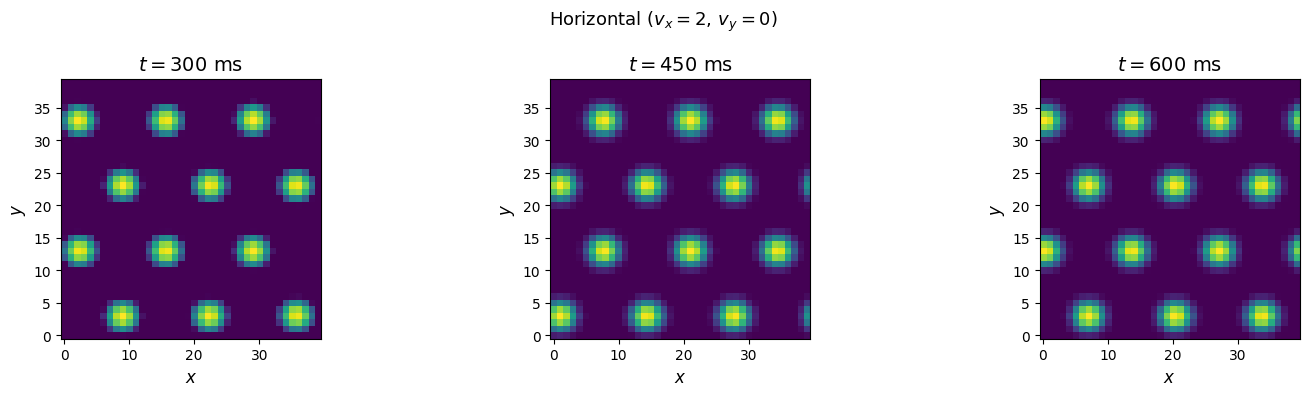

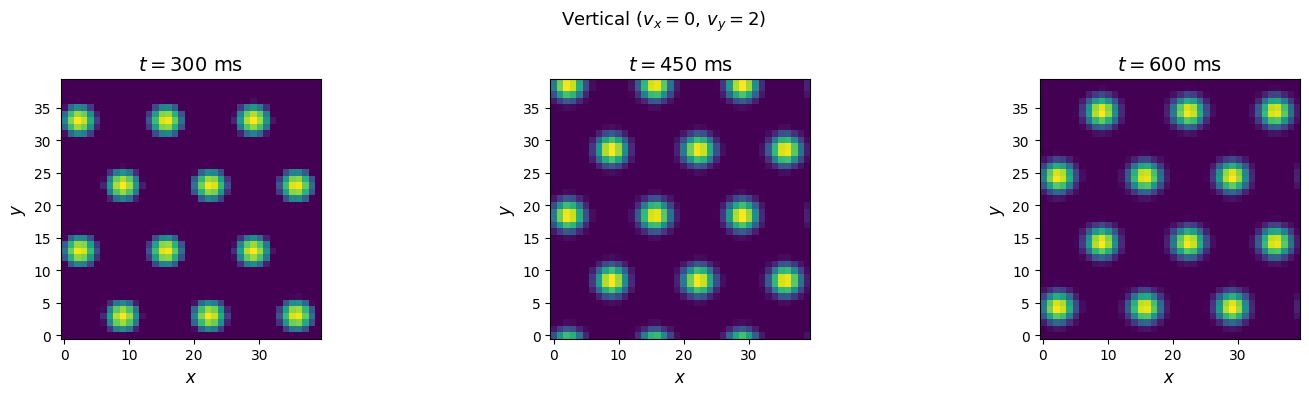

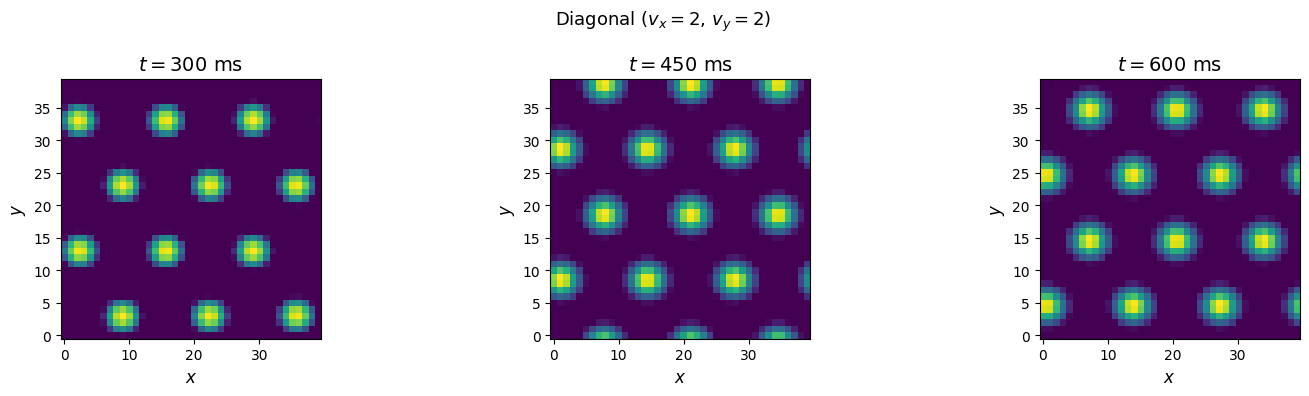

In [23]:
# ── Exercise 2.3 ─────────────────────────────────────────────────────────────

directions = {
    'Horizontal ($v_x=2,\,v_y=0$)': (2.0, 0.0),
    'Vertical ($v_x=0,\,v_y=2$)':   (0.0, 2.0),
    'Diagonal ($v_x=2,\,v_y=2$)':   (2.0, 2.0),
}

T23  = 601.0          # slightly > 600 so t=600 is included
n23  = int(T23 / dt)
time_23 = np.arange(n23) * dt

for title, (vx_val, vy_val) in directions.items():
    vx_arr = np.where(time_23 >= 300, vx_val, 0.0)
    vy_arr = np.where(time_23 >= 300, vy_val, 0.0)

    _, snaps = simulate_2d(vx_arr, vy_arr, T23)

    # We want snapshots at t = 300, 450, 600
    # Collect up to 3 (some may be missing if simulation ended early)
    snap_labels = [300, 450, 600]
    snap_dict   = {int(ts): img for ts, img in snaps}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, tl in zip(axes, snap_labels):
        if tl in snap_dict:
            ax.imshow(snap_dict[tl], origin='lower', cmap='viridis')
            ax.set_title(f'$t = {tl}$ ms')
        else:
            ax.set_visible(False)
        ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


**Observation and Discussion (Ex 2.3):**

The asymmetric modulation of the feedforward drive, combined with the anatomically shifted recurrent kernels, systematically biases the network's excitation. This forces the entire hexagonal lattice to translate rigidly, performing exact 2D path integration. The grid's spatial phase rigorously encodes the integrated position: $\boldsymbol{\phi}(t) = \boldsymbol{\phi}(0) + \kappa \int_0^t \mathbf{v}(t')\,dt'$. The intrinsic lattice parameters (spacing and orientation) remain strictly invariant, as they are determined exclusively by the symmetric Mexican-hat connectivity.


---
## Exercise 3 — Aperiodic Boundaries

Periodic (torus) boundaries are biologically implausible. We now consider aperiodic boundaries:
outgoing connections beyond the network edge are simply omitted (equivalent to
`mode='constant'` in `scipy.ndimage.convolve`).

$$I^{rec}(\mathbf{x},t)=\int_0^M\int_0^M W(\mathbf{x}-\mathbf{x}')\,r(\mathbf{x}',t)\,d x'\,dy'$$

**3.1.** Repeat the simulation from Ex. 2.2 with aperiodic boundaries. Describe what you see.


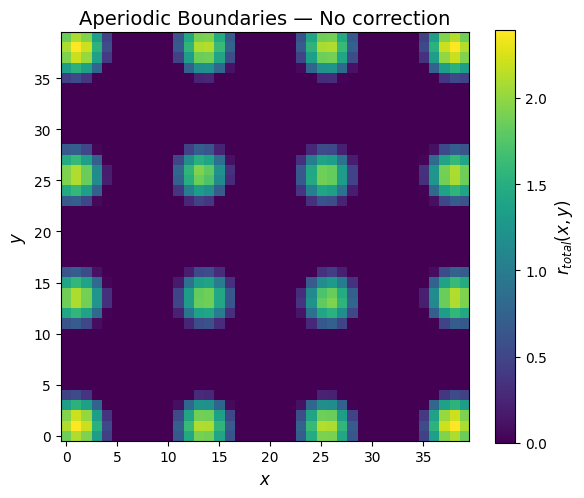

In [24]:
# ── Exercise 3.1 ─────────────────────────────────────────────────────────────

r31, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22, mode='constant')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r31, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title('Aperiodic Boundaries — No correction')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**Observation (Ex 3.1) — Mechanism:**

The truncation of the continuous attractor sheet structurally removes the long-range inhibitory surround for boundary neurons. This asymmetric loss fundamentally disrupts the center-surround competition mandated by the Mexican-hat kernel. Consequently, peripheral neurons receive a net recurrent excitatory current that permanently drives their activity above threshold, saturating the network edges and suppressing the interior grid pattern.


**3.2.** Compute and plot the 2D radial masking envelope $e(\mathbf{x})$:

$$e(\mathbf{x}) = \exp\!\left(-\gamma^2\,\max(0,\,|\mathbf{x}|-R_{fade})^2\right)$$

with $\gamma=0.08$, $f_{ratio}=0.2$, $M=50$, $R_{fade}=f_{ratio}\times M/2$.


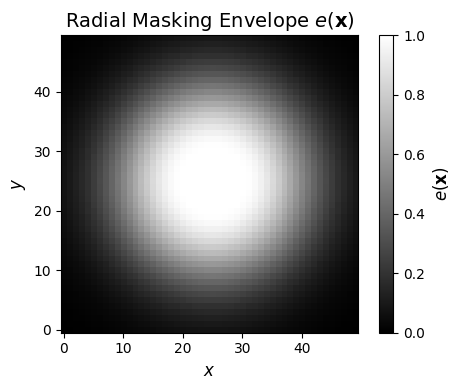

In [25]:
# ── Exercise 3.2 ─────────────────────────────────────────────────────────────

M3      = 50
gamma_e = 0.08
f_ratio = 0.2
R_fade  = f_ratio * (M3 / 2)

gy3, gx3 = np.mgrid[-M3//2 : M3//2, -M3//2 : M3//2]
dist3  = np.sqrt(gx3**2 + gy3**2)
e_mask = np.exp(-(gamma_e**2) * np.maximum(0.0, dist3 - R_fade)**2)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(e_mask, origin='lower', cmap='gray', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='$e(\mathbf{x})$')
ax.set_title('Radial Masking Envelope $e(\mathbf{x})$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**3.3.** Modify the network so that the **outgoing weights** of boundary neurons are scaled by
$e(\mathbf{x})$ (equivalent to multiplying the firing rate by $e(\mathbf{x})$ before
convolution). Simulate with $\mathbf{v}=(0,0)$ and plot the final activity.


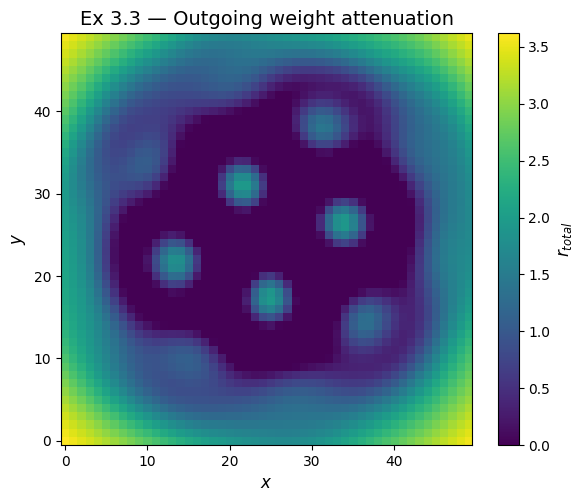

In [26]:
# ── Exercise 3.3 — Weight attenuation ────────────────────────────────────────

# Rebuild kernels for M=50
gy3k, gx3k = np.mgrid[-M3//2 : M3//2, -M3//2 : M3//2]
WN3 = mexican_hat_2d(gx3k,        gy3k - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WS3 = mexican_hat_2d(gx3k,        gy3k + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WE3 = mexican_hat_2d(gx3k - l2,   gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
WW3 = mexican_hat_2d(gx3k + l2,   gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
kernels3 = [WN3, WS3, WE3, WW3]

n33  = int(T22 / dt)
r33, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     weight_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r33, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.3 — Outgoing weight attenuation')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**Observation (Ex 3.3):**

The hexagonal grid successfully re-emerges in the unattenuated central region ($\approx 40\times 40$). By scaling down their efferent projections, boundary neurons exert a negligible influence on the recurrent dynamics, preventing the unbounded accumulation of excitatory activity caused by the asymmetric loss of the inhibitory surround.


**3.4.** Instead of attenuating the weights, multiply the feedforward inputs
$B_N, B_S, B_E, B_W$ by the envelope $e(\mathbf{x})$. Repeat and plot as in Ex. 3.3.


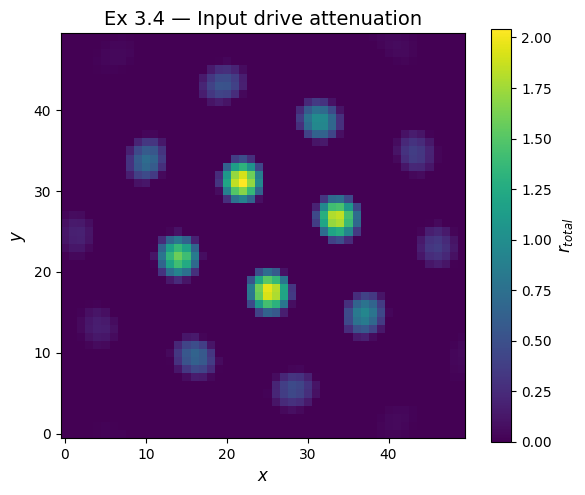

In [27]:
# ── Exercise 3.4 — Input attenuation ─────────────────────────────────────────

r34, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     input_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r34, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.4 — Input drive attenuation')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()


**Observation (Ex 3.4):**

The second correction strategy retains intact recurrent weights but modulates the feedforward baseline drives ($B_{N,S,E,W}$) by multiplying them directly by the spatial envelope $e(\mathbf{x})$. Consequently, peripheral neurons receive a significantly reduced external excitatory drive. This naturally confines their baseline potential below the firing threshold without artificially restricting their recurrent synaptic projections.


**3.5. Comparison of the two boundary correction approaches**

| | Ex 3.3 — Weight attenuation | Ex 3.4 — Input attenuation |
|---|---|---|
| **What is scaled** | Efferent firing rates $r(\mathbf{x}, t)$ strictly before recurrent convolution | Feedforward baseline drives $B_{N,S,E,W}$ locally at each neuron |
| **Mechanism** | Anatomically scales down the recurrent synaptic projections emitted by peripheral neurons | Reduces external excitatory afferents without altering the intrinsic recurrent connectivity manifold |
| **Pattern quality** | Hexagonal lattice restored centrally; peripheral neurons are strictly sub-threshold (silent) | Hexagonal lattice restored centrally; boundary neurons maintain partial baseline activity |
| **Biological analogue** | Decreased efferent axonal arborization (projection density) towards the MEC borders | Decreased density of thalamic/hippocampal afferents or lower intrinsic excitability of MEC layer-II stellate cells |

Neither approach is strictly superior for static pattern formation ($\mathbf{v}=0$): both successfully restore the spontaneous hexagonal lattice in the network interior. However, their dynamical implications diverge fundamentally during locomotion. Weight attenuation structurally alters the recurrent connectivity manifold, which explicitly breaks the continuous translation invariance of the network and inevitably induces grid distortion during active shifting.

In contrast, input attenuation strictly preserves the symmetric recurrent weights required for the continuous attractor dynamics, merely confining the excitatory driving force to the network center. As formally demonstrated by Burak & Fiete (2009), this input-attenuation strategy (implemented via their spatial envelope $A(\mathbf{x})$) is computationally necessary and sufficient to eliminate boundary-induced distortions and guarantee mathematically precise path integration during continuous velocity integration (Exercise 3.6).


---
## Exercise 4 — Final Question (Biology-Oriented)

**Model prediction to test.**
The CAN model precisely predicts that: (i) the hexagonal grid pattern emerges spontaneously from the center-surround (Mexican-hat) recurrent connectivity, rather than being anatomically hard-wired; (ii) the spatial phase of the grid (the internal position estimate) updates continuously and linearly by strictly integrating the velocity vector; and (iii) eliminating the asymmetric feedforward velocity modulation (i.e., setting $\alpha = 0$) preserves the stationary grid lattice but completely abolishes path integration.

**Proposed experiment.**

1. *Preparation.* Chronically implant high-density extracellular probes (e.g., Neuropixels) in the medial entorhinal cortex (MEC, layer II) of rats navigating a 1D linear track ($L=2$ m). Identify grid cells via their spatial periodicity (field spacing $\lambda$). Simultaneously record from head direction and speed-modulated cells (e.g., in the presubiculum) to extract a continuous ground-truth velocity signal $\mathbf{v}(t)$.

2. *Velocity-gain manipulation.* Employ a closed-loop virtual reality system to decouple physical locomotion from optic flow. Present a virtual optic flow scaled by a gain factor $\kappa$ relative to the physical treadmill speed ($\mathbf{v}_{virtual} = \kappa \mathbf{v}_{physical}$). Because the CAN model integrates the perceived velocity, it predicts the physical grid spacing will inversely scale by $1/\kappa$, reflecting an integration phase that accumulates at $\kappa v$ rather than $v$.

3. *Optogenetic perturbation.* Express soma-targeted excitatory opsins (e.g., ChR2) in the medial septum, which paces the theta-rhythm carrier oscillation conveying velocity signals to the MEC. Optogenetically stimulate this pathway in a stationary animal, modulating the amplitude to inject a synthetic asymmetric velocity signal. The CAN model dictates that this will force the network's continuous attractor to translate, inducing a predictable 'virtual' spatial displacement mathematically equal to the time-integral of the injected velocity.

4. *Readout.* Decode the instantaneous spatial phase from the multi-unit MEC population activity using a population vector estimator (calibrated during free-running sessions). By continuously comparing the decoded neural trajectory $x_{neural}(t)$ against the actual position $x_{actual}(t)$, quantify the path integration error. A systematic drift $x_{neural}(t) - x_{actual}(t) \propto t$ would directly reflect intrinsic structural heterogeneities or parameter mismatches (e.g., in $\alpha$, $l$, or $\sigma_{exc}$) within the biological CAN.

5. *Additional model module.* To quantitatively bridge the theoretical CAN model and biological data, the architecture requires two extensions: (a) a theta-rhythm oscillatory module ($\sim 8$ Hz) to realistically mediate the periodic velocity-signal updates observed in rodent MEC; and (b) a downstream hippocampal place-cell decoder that integrates the phases of multiple grid modules to yield an unambiguous position estimate, allowing direct evaluation of simulated versus experimental spatial drift.
